## Part 1: Helping functions and data loading

In [9]:
# Do not modify this cell, this is only for ploting the clusters
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")

    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.show()

In [10]:
# loading data
import numpy as np
X = np.load("part1_data.npz")["X"]

## K-means experiments

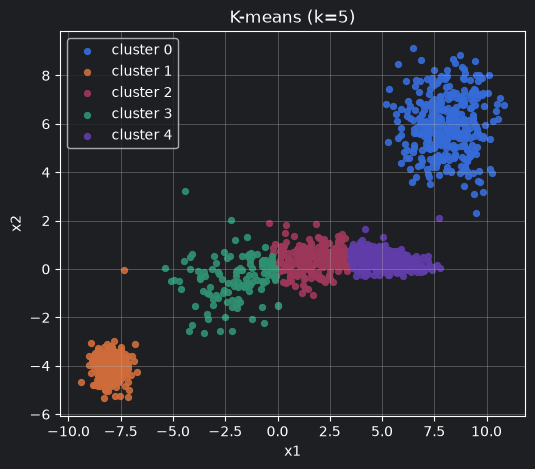

In [11]:
from sklearn.cluster import KMeans

# Number of clusters
K = 5

# Fit K-means and get labels
km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
labels = km.labels_

# ploting data
plot_clustering_result(X, labels, title=f"K-means (k={K})")

### K-Means Discussion

Comparing K = 2 through K = 5 visually, **K = 3 best matches the data's structure:** it cleanly isolates both the top right and bottom left while also revealing the middle cluster as a third visible region, whereas K = 2 hides that middle portion by splitting and absorbing it into the nearest blob.

K = 4 and K = 5 isolate the blobs too, but arbitrarily slice the middle part into two or three pieces despite no visible gap justifying a split — clear over-segmentation.

This matches the WCSS/silhouette evaluation (which was something I added as an extra thing), where K = 3 gives the highest silhouette score (0.6966) right where the elbow flattens out.

Still, separation isn't perfect at K = 3: the middle part's left tail blends into the bottom-left blob since it curves toward it with no clear gap, so K-means pulls those points into the nearer cluster.

Overall, K = 3 best balances the visual and quantitative evidence, avoiding both K = 2's under-segmentation and K = 4/K = 5's unjustified splitting.

*AI Declaration: I used AI to make the evaluation metric methods*

## DBSCAN experiments

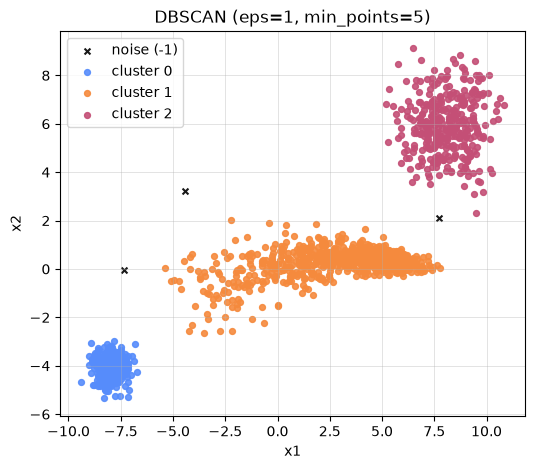

In [28]:
import numpy as np
from sklearn.cluster import DBSCAN

# Vary these
EPS = 1          # epsilon=neighbourhood radius
MIN_POINTS = 5     # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, title=f"DBSCAN (eps={EPS}, min_points={MIN_POINTS})")

DBSCAN Discussion